# Plot pipelines: Have a look at the unclustered gas pipelines

Goal: rebuild the plot_gas_network function that is currently commented out in prepare_gas_network

## Import packages

In [49]:
import io
import logging
import os
import shutil
import subprocess
import sys
import time
import zipfile
from pathlib import Path

import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import os
import geopandas as gpd
import numpy as np
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
from shapely import wkt
import hvplot.pandas
from matplotlib.lines import Line2D
from pyproj import CRS
from fake_useragent import UserAgent
import requests
from shapely.geometry import LineString, Point
import country_converter as coco

## Content retrieve helpers

In [50]:
def content_retrieve(url, data=None, headers=None, max_retries=3, backoff_factor=0.3):
    """
    Retrieve the content of a url with improved robustness.

    This function uses a more robust approach to handle permission issues
    and avoid being blocked by the server. It implements exponential backoff
    for retries and rotates user agents.

    Parameters
    ----------
    url : str
        URL to retrieve the content from
    data : dict, optional
        Data for the request, by default None
    headers : dict, optional
        Headers for the request, defaults to a fake user agent
        If no headers are wanted at all, pass an empty dict.
    max_retries : int, optional
        Maximum number of retries, by default 3
    backoff_factor : float, optional
        Factor to apply between attempts, by default 0.3
    """
    if headers is None:
        ua = UserAgent()
        headers = {
            "User-Agent": ua.random,
            "Upgrade-Insecure-Requests": "1",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
            "Accept-Language": "en-US,en;q=0.5",
            "Accept-Encoding": "gzip, deflate, br",
            "DNT": "1",
            "Connection": "keep-alive",
            "Referer": "https://www.google.com/",
        }

    session = requests.Session()

    for i in range(max_retries):
        try:
            response = session.get(url, headers=headers, data=data)
            response.raise_for_status()
            return io.BytesIO(response.content)
        except (
            requests.exceptions.RequestException,
            requests.exceptions.HTTPError,
        ) as e:
            if i == max_retries - 1:  # last attempt
                raise
            else:
                # Exponential backoff
                wait_time = backoff_factor * (2**i) + np.random.uniform(0, 0.1)
                time.sleep(wait_time)

                # Rotate user agent for next attempt
                headers["User-Agent"] = UserAgent().random

    raise Exception("Max retries exceeded")

## Convert two to three digits contry code helper 

In [51]:
def three_2_two_digits_country(three_code_country):
    """
    Convert 3-digit to 2-digit country code:

    Parameters
    ----------
    three_code_country: str
        3-digit country name

    Returns
    ----------
    two_code_country: str
        2-digit country name
    """
    if three_code_country == "SEN-GMB":
        return f"{three_2_two_digits_country('SN')}-{three_2_two_digits_country('GM')}"

    two_code_country = coco.convert(three_code_country, to="ISO2")
    return two_code_country

## Pipeline data conversion helpers

In [52]:
def diameter_to_capacity(pipe_diameter_mm):
    """
    Calculate pipe capacity in MW based on diameter in mm.

    20 inch (500 mm)  50 bar -> 1.5   GW CH4 pipe capacity (LHV) 24 inch
    (600 mm)  50 bar -> 5     GW CH4 pipe capacity (LHV) 36 inch (900
    mm)  50 bar -> 11.25 GW CH4 pipe capacity (LHV) 48 inch (1200 mm) 80
    bar -> 21.7  GW CH4 pipe capacity (LHV)

    Based on p.15 of
    https://gasforclimate2050.eu/wp-content/uploads/2020/07/2020_European-Hydrogen-Backbone_Report.pdf
    """
    # slopes definitions
    m0 = (1500 - 0) / (500 - 0)
    m1 = (5000 - 1500) / (600 - 500)
    m2 = (11250 - 5000) / (900 - 600)
    m3 = (21700 - 11250) / (1200 - 900)

    # intercept
    a0 = 0
    a1 = -16000
    a2 = -7500
    a3 = -20100

    if pipe_diameter_mm < 500:
        return a0 + m0 * pipe_diameter_mm
    elif pipe_diameter_mm < 600:
        return a1 + m1 * pipe_diameter_mm
    elif pipe_diameter_mm < 900:
        return a2 + m2 * pipe_diameter_mm
    else:
        return a3 + m3 * pipe_diameter_mm


def inch_to_mm(len_inch):
    return len_inch / 0.0393701


def bcm_to_MW(cap_bcm):
    return cap_bcm * 9769444.44 / 8760


def correct_Diameter_col(value):
    value = str(value)
    # Check if the value contains a comma
    if "," in value:
        # Split the value by comma and convert each part to a float
        diameter_values = [float(val) for val in value.split(",")]
        # Calculate the mean of the values
        return sum(diameter_values) / len(diameter_values)
    elif "/" in value:
        # Split the value by slash and convert each part to a float
        diameter_values = [float(val) for val in value.split("/")]
        # Calculate the mean of the values
        return sum(diameter_values) / len(diameter_values)
    elif "-" in value:
        # Split the value by slash and convert each part to a float
        diameter_values = [float(val) for val in value.split("-")]
        # Calculate the mean of the values
        return sum(diameter_values) / len(diameter_values)
    else:
        # Return the original value for rows without a comma or slash
        return float(value)

## Download GGIT gas data network

In [53]:
def download_GGIT_gas_network():
    """
    Downloads a global dataset for gas networks as .xlsx.

    The following xlsx file was downloaded from the webpage
    https://globalenergymonitor.org/projects/global-gas-infrastructure-tracker/
    The dataset contains 3144 pipelines.
    """
    url = "https://globalenergymonitor.org/wp-content/uploads/2022/12/GEM-GGIT-Gas-Pipelines-December-2022.xlsx"
    GGIT_gas_pipeline = pd.read_excel(
        content_retrieve(url),
        index_col=0,
        sheet_name="Gas Pipelines 2022-12-16",
        header=0,
    )

    return GGIT_gas_pipeline

## Prepare GGIT data

In [54]:
def prepare_GGIT_data(GGIT_gas_pipeline):
    df = GGIT_gas_pipeline.copy().reset_index()

    # Drop rows containing "--" in the 'WKTFormat' column
    df = df[df["WKTFormat"] != "--"]

    # Keep pipelines that are as below
    #df = df[df["Status"].isin(snakemake.params.gas_config["network_data_GGIT_status"])]
    df = df[df["Status"].isin(["Construction", "Operating", "Idle", "Shelved", "Mothballed", "Proposed"])]

    # Convert the WKT column to a GeoDataFrame
    df = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["WKTFormat"]))

    # Set the CRS to EPSG:4326
    df.crs = CRS.from_epsg(4326)

    # Convert CRS to EPSG:3857 so we can measure distances
    df = df.to_crs(epsg=3857)

    # Convert and correct diameter column to be in mm
    df.loc[df["DiameterUnits"] == "mm", "diameter_mm"] = df.loc[
        df["DiameterUnits"] == "mm", "Diameter"
    ].apply(correct_Diameter_col)
    df.loc[df["DiameterUnits"] == "in", "diameter_mm"] = (
        df.loc[df["DiameterUnits"] == "in", "Diameter"]
        .apply(correct_Diameter_col)
        .apply(
            lambda d: inch_to_mm(float(d))
        )  #         .apply(lambda ds: pd.Series(ds).apply(lambda d: inch_to_mm(float(d))))
    )

    # Convert Bcm/y to MW
    df["CapacityBcm/y"] = pd.to_numeric(df["CapacityBcm/y"], errors="coerce")
    df["capacity [MW]"] = df["CapacityBcm/y"].apply(lambda d: bcm_to_MW(d))

    # Get capacity from diameter for rows where no capacity is given
    df.loc[df["CapacityBcm/y"] == "--", "capacity [MW]"] = df.loc[
        df["CapacityBcm/y"] == "--", "diameter_mm"
    ].apply(lambda d: diameter_to_capacity(int(d)))
    df["diameter_mm"] = pd.to_numeric(
        df["diameter_mm"], errors="coerce", downcast="integer"
    )
    df.loc[pd.isna(df["CapacityBcm/y"]), "capacity [MW]"] = df.loc[
        pd.isna(df["CapacityBcm/y"]), "diameter_mm"
    ].apply(lambda d: diameter_to_capacity(d))

    return df

## Order and parse states

In [55]:
def get_states_in_order(pipeline, bus_regions_onshore):
    states_p = []

    if pipeline.geom_type == "LineString":
        # Interpolate points along the LineString with a given step size (e.g., 5)
        step_size = 10000
        interpolated_points = [
            pipeline.interpolate(i) for i in range(0, int(pipeline.length), step_size)
        ]
        interpolated_points.append(
            pipeline.interpolate(pipeline.length)
        )  # Add the last point

    elif pipeline.geom_type == "MultiLineString":
        interpolated_points = []
        # Iterate over each LineString within the MultiLineString
        for line in pipeline.geoms:
            # Interpolate points along each LineString with a given step size (e.g., 5)
            step_size = 10000
            interpolated_points_line = [
                line.interpolate(i) for i in range(0, int(line.length), step_size)
            ]
            interpolated_points_line.append(
                line.interpolate(line.length)
            )  # Add the last point
            interpolated_points.extend(interpolated_points_line)

    # Check each interpolated point against the state geometries
    for point in interpolated_points:
        for index, state_row in bus_regions_onshore.iterrows():
            if state_row.geometry.contains(point):
                gadm_id = state_row["gadm_id"]
                if gadm_id not in states_p:
                    states_p.append(gadm_id)
                break  # Stop checking other states once a match is found

    return states_p

def parse_states(pipelines, bus_regions_onshore):
    # Parse the states of the points which are connected by the pipeline geometry object
    pipelines["nodes"] = None
    pipelines["states_passed"] = None
    pipelines["amount_states_passed"] = None

    for pipeline, row in pipelines.iterrows():
        states_p = get_states_in_order(row.geometry, bus_regions_onshore)
        # states_p = pd.unique(states_p)
        row["states_passed"] = states_p
        row["amount_states_passed"] = len(states_p)
        row["nodes"] = list(zip(states_p[0::1], states_p[1::1]))
        pipelines.loc[pipeline] = row
    print(
        "The maximum number of states which are passed by one single pipeline amounts to {}.".format(
            pipelines.states_passed.apply(lambda n: len(n)).max()
        )
    )
    return pipelines

## Plotting function (unclustered)

In [56]:
def plot_gas_network(pipelines, country_borders, bus_regions_onshore):
    df = pipelines.copy()
    df = gpd.overlay(df, country_borders, how="intersection")

    #if snakemake.params.gas_config["network_data"] == "IGGIELGN":
    #    df = df.rename({"p_nom": "capacity [MW]"}, axis=1)

    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(12, 7)
    bus_regions_onshore.to_crs(epsg=3857).plot(
        ax=ax, color="white", edgecolor="darkgrey", linewidth=0.5
    )
    df.loc[(df.amount_states_passed > 1)].to_crs(epsg=3857).plot(
        ax=ax,
        column="capacity [MW]",
        linewidth=2.5,
        # linewidth=df['capacity [MW]'],
        # alpha=0.8,
        categorical=False,
        cmap="viridis_r",
        # legend=True,
        # legend_kwds={'label':'Pipeline capacity [MW]'},
    )

    df.loc[(df.amount_states_passed <= 1)].to_crs(epsg=3857).plot(
        ax=ax,
        column="capacity [MW]",
        linewidth=2.5,
        # linewidth=df['capacity [MW]'],
        alpha=0.5,
        categorical=False,
        # color='darkgrey',
        ls="dotted",
    )

    # # Create custom legend handles for line types
    # line_types = [ 'solid', 'dashed', 'dotted'] # solid
    # legend_handles = [Line2D([0], [0], color='black', linestyle=line_type) for line_type in line_types]

    # Define line types and labels
    line_types = ["solid", "dotted"]
    line_labels = ["Operating", "Not considered \n(within-state)"]

    # Create custom legend handles for line types
    legend_handles = [
        Line2D([0], [0], color="black", linestyle=line_type, label=line_label)
        for line_type, line_label in zip(line_types, line_labels)
    ]

    # Add the line type legend
    ax.legend(
        handles=legend_handles,
        title="Status",
        borderpad=1,
        title_fontproperties={"weight": "bold"},
        fontsize=11,
        loc=1,
    )

    # # create the colorbar
    norm = colors.Normalize(
        vmin=df["capacity [MW]"].min(), vmax=df["capacity [MW]"].max()
    )
    cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis_r")
    # fig.colorbar(cbar, ax=ax).set_label('Capacity [MW]')

    # add colorbar
    ax_cbar = fig.colorbar(cbar, ax=ax, location="left", shrink=0.8, pad=0.01)
    # add label for the colorbar
    ax_cbar.set_label("Natural gas pipeline capacity [MW]", fontsize=15)

    ax.set_axis_off()
    #fig.savefig(snakemake.output.gas_network_fig_1, dpi=300, bbox_inches="tight")
    fig.show()

## Plotting function (clustered)

In [57]:
def plot_clustered_gas_network(pipelines, bus_regions_onshore):
    # Create a new GeoDataFrame with centroids
    centroids = bus_regions_onshore.copy()
    centroids["geometry"] = centroids["geometry"].centroid
    centroids["gadm_id"] = centroids["gadm_id"].apply(
        lambda id: three_2_two_digits_country(id[:3]) + id[3:]
    )
    gdf1 = pd.merge(
        pipelines, centroids, left_on=["bus0"], right_on=["gadm_id"], how="left"
    )
    gdf1.rename(columns={"geometry": "geometry_bus0"}, inplace=True)
    pipe_links = pd.merge(
        gdf1, centroids, left_on=["bus1"], right_on=["gadm_id"], how="left"
    )
    pipe_links.rename(columns={"geometry": "geometry_bus1"}, inplace=True)

    # Create LineString geometries from the points
    pipe_links["geometry"] = pipe_links.apply(
        lambda row: LineString([row["geometry_bus0"], row["geometry_bus1"]]), axis=1
    )

    clustered = gpd.GeoDataFrame(pipe_links, geometry=pipe_links["geometry"])

    # Optional: Set the coordinate reference system (CRS) if needed
    clustered.crs = "EPSG:3857"  # For example, WGS84

    # plot pipelines
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(12, 7)
    bus_regions_onshore.to_crs(epsg=3857).plot(
        ax=ax, color="white", edgecolor="darkgrey", linewidth=0.5
    )
    clustered.to_crs(epsg=3857).plot(
        ax=ax,
        column="capacity",
        linewidth=1.5,
        categorical=False,
        cmap="plasma",
    )

    centroids.to_crs(epsg=3857).plot(
        ax=ax,
        color="red",
        markersize=35,
        alpha=0.5,
    )

    norm = colors.Normalize(
        vmin=pipelines["capacity"].min(), vmax=pipelines["capacity"].max()
    )
    cbar = plt.cm.ScalarMappable(norm=norm, cmap="plasma")

    # add colorbar
    ax_cbar = fig.colorbar(cbar, ax=ax, location="left", shrink=0.8, pad=0.01)
    # add label for the colorbar
    ax_cbar.set_label("Natural gas pipeline capacity [MW]", fontsize=15)

    ax.set_axis_off()
    #fig.savefig(snakemake.output.gas_network_fig_2, dpi=300, bbox_inches="tight")
    fig.show()

## Load bus regions

## Actual run

In [58]:
pipelines_raw = download_GGIT_gas_network()

In [59]:
pipelines_prepared = prepare_GGIT_data(pipelines_raw)

### Import bus_region and country borders

Data is generated by load_bus_regions and manually put in the folder

In [60]:
regions_onshore = gpd.read_file('bus_regions_onshore.geojson')
country_borders = gpd.read_file('country_borders.geojson')

### Parse states

In [61]:
pipelines_parsed = parse_states(pipelines_prepared, regions_onshore)

The maximum number of states which are passed by one single pipeline amounts to 11.


In [ ]:
pipelines_parsed.to_file('pipelines_parsed.geojson', driver="GeoJSON")

### Plot network

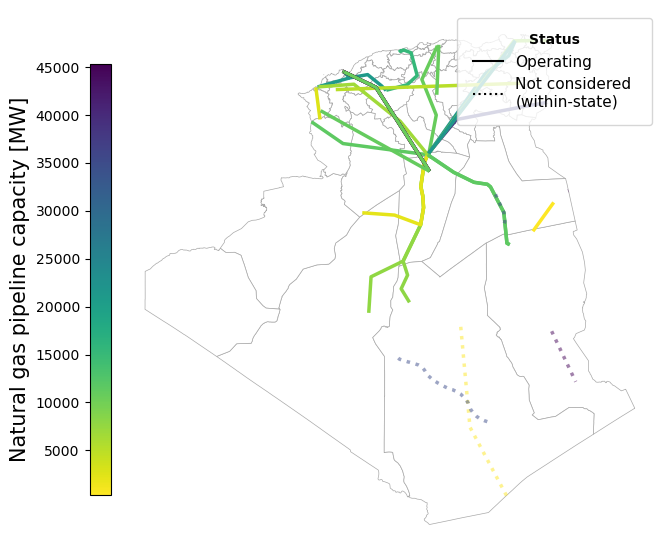

In [62]:
plot_gas_network(pipelines_parsed, country_borders, regions_onshore)

In [63]:
pipelines_parsed.loc[pipelines_parsed['nodes'].astype(bool)].head(5)

,ProjectID,Fuel,StartCountry,EndCountry,Countries,Wiki,PipelineName,SegmentName,OtherEnglishNames,Owner,...,OtherLanguagePrimaryPipelineName,OtherLanguageSegmentName,OtherLanguageWikiPage,WKTFormat,geometry,diameter_mm,capacity [MW],nodes,states_passed,amount_states_passed
240,P0453,Gas,Algeria,Spain,"Algeria, Morocco, Spain, Portugal",https://www.gem.wiki/Maghreb-Europe_Gas_Pipeline,Maghreb-Europe Gas Pipeline,NaN,Europe-Maghreb Pipeline (EMPL),Enagás [unknown %]; Government of Morocco [unk...,...,"خط أنابيب غازالمغرب العربي-أوروبا, بيدرو دوران...",NaN,NaN,"LINESTRING (3.2514804 32.9358193, -0.3197216 3...","LINESTRING (361953.142 3886788.144, -35591.246...",NaN,13382.800603,"[(DZA.25_1, DZA.17_1), (DZA.17_1, DZA.31_1)]","[DZA.25_1, DZA.17_1, DZA.31_1]",3
251,P0465,Gas,Algeria,Algeria,Algeria,https://www.gem.wiki/Haoudh_El_Hamra-Arzew_Gas...,Haoudh El Hamra-Arzew Gas Pipeline,NaN,NaN,Sonatrach [100.00%],...,NaN,NaN,NaN,"LINESTRING (5.7348 32.0173, 5.2074 31.9547, 4....","LINESTRING (638395.016 3765581.735, 579685.116...",NaN,NaN,"[(DZA.33_1, DZA.20_1), (DZA.20_1, DZA.25_1), (...","[DZA.33_1, DZA.20_1, DZA.25_1, DZA.43_1, DZA.3...",7
252,P0466,Gas,Algeria,Algeria,Algeria,https://www.gem.wiki/Hassi_R'Mel-Arzew_Gas_Pip...,Hassi R'Mel-Arzew Gas Pipeline,Mainline,GZ0,Sonatrach [100.00%],...,أنبوب الغاز حاسي الرمل - أرزيو,NaN,NaN,"LINESTRING (3.331794904 32.34731415, 1.0699742...","LINESTRING (370893.712 3808987.85, 119108.987 ...",NaN,7527.825339,"[(DZA.20_1, DZA.25_1), (DZA.25_1, DZA.43_1), (...","[DZA.20_1, DZA.25_1, DZA.43_1, DZA.27_1, DZA.3...",7
253,P0467,Gas,Algeria,Algeria,Algeria,https://www.gem.wiki/Hassi_R'mel-Isser_Gas_Pip...,Hassi R'Mel-Isser Gas Pipeline,NaN,GG1، Hassi R'Mel- Bordj Ménail Gas Pipeline,Sonatrach [100.00%],...,أنبوب غاز حاسي رمل – برج منايل,NaN,NaN,"LINESTRING (3.291 32.928, 3.614 34.33, 3.007 3...","LINESTRING (366352.444 3885751.062, 402308.64 ...",1066.799424,12602.137234,"[(DZA.25_1, DZA.20_1), (DZA.20_1, DZA.16_1), (...","[DZA.25_1, DZA.20_1, DZA.16_1, DZA.28_1, DZA.1...",6
254,P0468,Gas,Algeria,Algeria,Algeria,https://www.gem.wiki/Hassi_R'Mel-Skikda_Gas_Pi...,Hassi R'Mel-Skikda Gas Pipeline,NaN,GK1,Sonatrach [100.00%],...,أنبوب الغاز حاسي الرمل -سكسيدا,NaN,NaN,"LINESTRING (3.283 32.972, 5.67 35.751, 6.669 3...","LINESTRING (365461.888 3891588.021, 631181.513...",1015.999451,22828.827362,"[(DZA.25_1, DZA.16_1), (DZA.16_1, DZA.9_1), (D...","[DZA.25_1, DZA.16_1, DZA.9_1, DZA.26_1, DZA.6_...",9


### Plot clustered network

In [64]:
plot_clustered_gas_network(pipelines_parsed, regions_onshore)

KeyError: 'bus0'